In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

df=pd.read_csv(r"C:\Users\Vaish\Desktop\ML LAB DATASETS LOGISTIC REGRESSION\BATCH-6\30_service_upgrade.csv")


In [14]:
print("------------HEAD---------------")
print(df.head())
print("-----------TAIL-----------------")
print(df.tail())
print("--------------DESCRIBE-----------")
print(df.describe())
print("----------------INFO-------------")
print(df.info())
print("--------------------MISSING VALUES----------------")
print(df.isnull().sum())


------------HEAD---------------
   usage_pct_of_limit  tenure_months  support_tickets  \
0               67.17          40.23                6   
1               37.11          48.92                8   
2               83.27          58.04               10   
3               50.22          27.34                3   
4               55.49          14.01               10   

   price_sensitivity_score device_type  os_type subscription_type  \
0                     6.51     Desktop  Android              Free   
1                     8.74     Desktop      iOS              Free   
2                     6.98      Tablet  Android           Premium   
3                     9.55      Laptop      iOS           Premium   
4                     8.21       Phone      iOS              Free   

   upgraded_plan  
0              0  
1              1  
2              0  
3              0  
4              0  
-----------TAIL-----------------
     usage_pct_of_limit  tenure_months  support_tickets  \
295 

In [15]:
X = df.drop("upgraded_plan", axis=1)
y = df["upgraded_plan"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 11)
Testing data: (60, 11)


In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
z = model.decision_function(X_test)

probability = 1 / (1 + np.exp(-z))

print("Sigmoid probabilities:")
print(probability[:10])

Sigmoid probabilities:
[0.42917544 0.23664967 0.28288199 0.48902874 0.36086965 0.57421358
 0.60456835 0.05443565 0.18020606 0.58281031]


In [5]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Predicted labels:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[0 0 0 0 0 1 1 0 0 1]

Predicted probabilities:
[0.42917544 0.23664967 0.28288199 0.48902874 0.36086965 0.57421358
 0.60456835 0.05443565 0.18020606 0.58281031]


In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[24  7]
 [ 9 20]]
Accuracy: 0.7333333333333333
Precision: 0.7407407407407407
Recall: 0.6896551724137931
F1 Score: 0.7142857142857143


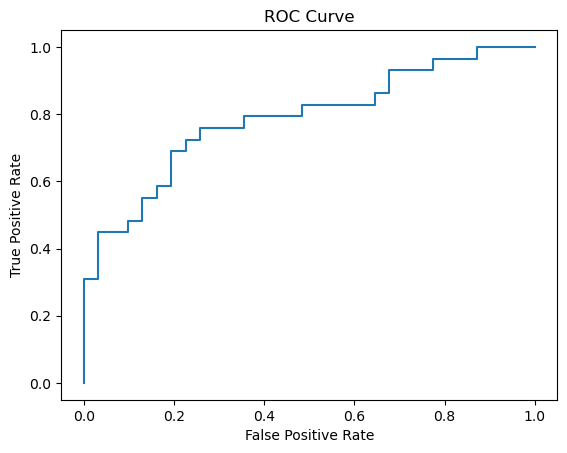

AUC: 0.7864293659621802


In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc)

In [20]:
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

print("Predictions with threshold 0.7:")
print(y_pred_new[:20])

Predictions with threshold 0.7:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0]


In [21]:
new_data = pd.DataFrame({
    "usage_pct_of_limit": [75],
    "tenure_months": [30],
    "support_tickets": [3],
    "price_sensitivity_score": [5],
    "device_type": ["Mobile"],
    "os_type": ["Android"],
    "subscription_type": ["Free"]
})

new_data = pd.get_dummies(new_data, drop_first=True)

new_data = new_data.reindex(columns=X.columns, fill_value=0)

new_probability = model.predict_proba(new_data)[:, 1]
new_prediction = (new_probability >= 0.7).astype(int)

print("Upgrade probability:", new_probability[0])
print("Prediction:", new_prediction[0])

Upgrade probability: 0.7428877499479741
Prediction: 1
